<a href="https://colab.research.google.com/github/Evsstah/data_analysis/blob/master/num1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ПРОГРАММА ДЛЯ ОПРЕДЕЛЕНИЯ ЦЕНТРОИДОВ КЛАСТЕРОВ ЗВЕЗД

Загрузка данных из файла: 27_B_17834.csv
Загружено 9900 точек
✓ Успешно загружено 9900 точек (звезд).
✓ Диапазон координат: X [-2.97, 10.97], Y [-3.97, 8.97]

Параметры анализа:
  - Радиус кластера R = 3
  - Количество кластеров = 3

Выполнение кластеризации...
ОТЧЕТ ПО РЕЗУЛЬТАТАМ КЛАСТЕРИЗАЦИИ ЗВЕЗД

1. ОБЩАЯ ИНФОРМАЦИЯ:
   Всего обработано звезд: 9900
   Радиус кластера (R): 3
   Количество кластеров: 3

2. КООРДИНАТЫ ЦЕНТРОИДОВ КЛАСТЕРОВ:
   Кластер 1: x = 0.5490, y = 5.0160
   Кластер 2: x = 4.1460, y = -0.2940
   Кластер 3: x = 7.5630, y = 5.8510

3. ХАРАКТЕРИСТИКИ КЛАСТЕРОВ:

   Кластер 1:
   - Количество звезд: 3500
   - Макс. расстояние до центроида: 3.5236
   - Среднее расстояние до центроида: 1.9018
   - Стандартное отклонение: 0.7378
   - Соответствие условию R=3: НЕТ
   ВНИМАНИЕ: 232 точек находятся дальше R=3 от центроида!

   Кластер 2:
   - Количество звезд: 3200
   - Макс. расстояние до центроида: 3.7025
   - Средне

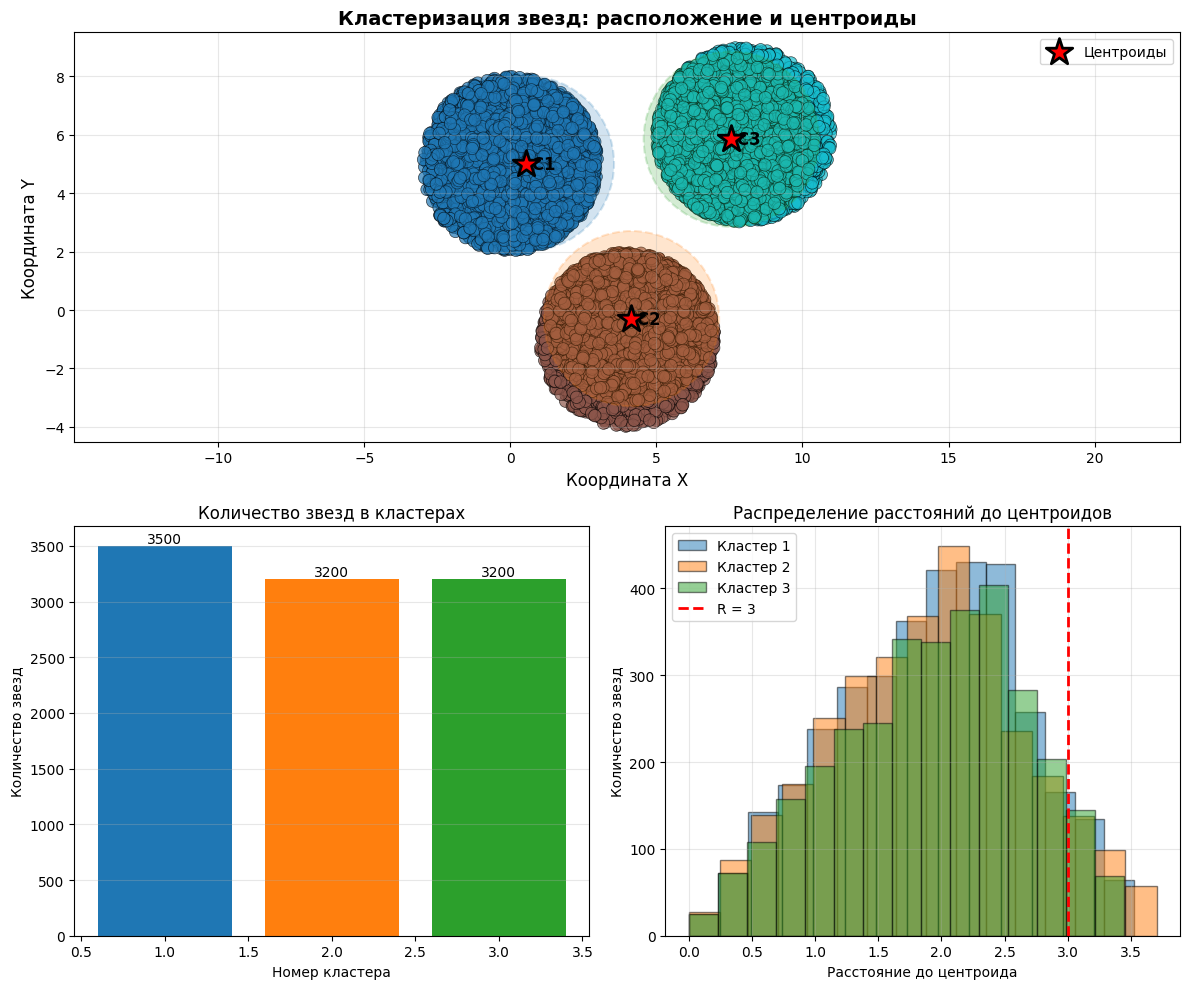

АНАЛИЗ ВЫПОЛНЕН УСПЕШНО!
ИТОГОВЫЕ КООРДИНАТЫ ЦЕНТРОИДОВ:
Кластер 1: (0.549000, 5.016000)
Кластер 2: (4.146000, -0.294000)
Кластер 3: (7.563000, 5.851000)


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

def load_data(filename):
    """Загрузка данных из CSV файла"""
    try:
        # Читаем CSV файл
        df = pd.read_csv(filename, sep=';', decimal=',')

        # Проверяем наличие нужных колонок
        if 'X' in df.columns and 'Y' in df.columns:
            data = df[['X', 'Y']].values
        elif len(df.columns) >= 2:
            # Если колонки называются иначе, берем первые две
            data = df.iloc[:, :2].values
        else:
            raise ValueError("Файл должен содержать как минимум 2 колонки с координатами")

        print(f"Загружено {len(data)} точек")
        return data

    except Exception as e:
        print(f"Ошибка при загрузке файла: {e}")
        return None

def find_cluster_centers(data, R=3, n_clusters=3):
    """
    Находит центроиды кластеров.
    В соответствии с условиями задачи, центроид - это одна из звезд кластера
    с минимальной суммой расстояний до других звезд кластера.
    """
    # Шаг 1: Используем K-means для начальной кластеризации
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)

    centroids = []

    for cluster_id in range(n_clusters):
        # Выбираем точки текущего кластера
        cluster_mask = labels == cluster_id
        cluster_points = data[cluster_mask]

        if len(cluster_points) == 0:
            continue

        # Шаг 2: Ищем точку с минимальной суммой расстояний до других точек кластера
        min_sum_dist = float('inf')
        best_point_idx = -1

        # Для каждой точки в кластере вычисляем сумму расстояний до других точек
        for i in range(len(cluster_points)):
            current_point = cluster_points[i]

            # Вычисляем евклидовы расстояния от текущей точки до всех других
            distances = np.sqrt(np.sum((cluster_points - current_point) ** 2, axis=1))
            sum_dist = np.sum(distances)

            if sum_dist < min_sum_dist:
                min_sum_dist = sum_dist
                best_point_idx = i

        # Найденная точка является центроидом
        centroids.append(cluster_points[best_point_idx])

    return np.array(centroids), labels


def analyze_results(data, centroids, labels, R=3):
    """Анализ результатов и вывод отчета"""

    print("ОТЧЕТ ПО РЕЗУЛЬТАТАМ КЛАСТЕРИЗАЦИИ ЗВЕЗД")

    print(f"\n1. ОБЩАЯ ИНФОРМАЦИЯ:")
    print(f"   Всего обработано звезд: {len(data)}")
    print(f"   Радиус кластера (R): {R}")
    print(f"   Количество кластеров: {len(centroids)}")

    print(f"\n2. КООРДИНАТЫ ЦЕНТРОИДОВ КЛАСТЕРОВ:")
    for i, centroid in enumerate(centroids):
        print(f"   Кластер {i+1}: x = {centroid[0]:.4f}, y = {centroid[1]:.4f}")

    print(f"\n3. ХАРАКТЕРИСТИКИ КЛАСТЕРОВ:")
    for i in range(len(centroids)):
        cluster_mask = labels == i
        cluster_points = data[cluster_mask]

        if len(cluster_points) > 0:
            # Расстояния от центроида до всех точек кластера
            distances = np.sqrt(np.sum((cluster_points - centroids[i]) ** 2, axis=1))

            print(f"\n   Кластер {i+1}:")
            print(f"   - Количество звезд: {len(cluster_points)}")
            print(f"   - Макс. расстояние до центроида: {np.max(distances):.4f}")
            print(f"   - Среднее расстояние до центроида: {np.mean(distances):.4f}")
            print(f"   - Стандартное отклонение: {np.std(distances):.4f}")
            print(f"   - Соответствие условию R={R}: {'ДА' if np.max(distances) <= R else 'НЕТ'}")

            # Проверка, что все точки находятся в пределах R от центроида
            if np.max(distances) > R:
                outliers = np.sum(distances > R)
                print(f"   ВНИМАНИЕ: {outliers} точек находятся дальше R={R} от центроида!")

    print(f"\n4. КАЧЕСТВО КЛАСТЕРИЗАЦИИ:")
    # Вычисляем сумму квадратов расстояний до центроидов (inertia)
    total_inertia = 0
    for i in range(len(centroids)):
        cluster_mask = labels == i
        if np.any(cluster_mask):
            distances_sq = np.sum((data[cluster_mask] - centroids[i]) ** 2)
            total_inertia += distances_sq

    print(f"   Общая сумма квадратов расстояний: {total_inertia:.4f}")
    print(f"   Среднее расстояние до центроида по всем точкам: {np.sqrt(total_inertia/len(data)):.4f}")


def visualize_clusters(data, labels, centroids, R=3):
    """Визуализация результатов кластеризации"""
    plt.figure(figsize=(12, 10))

    # 1. Основной график с кластерами
    plt.subplot(2, 2, (1, 2))
    scatter = plt.scatter(data[:, 0], data[:, 1], c=labels,
                         cmap='tab10', alpha=0.7, s=80, edgecolor='k', linewidth=0.5)

    # Отображаем центроиды
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='*',
               s=400, label='Центроиды', edgecolors='black', linewidth=2, zorder=5)

    # Рисуем круги радиусом R вокруг центроидов
    for i, centroid in enumerate(centroids):
        circle = plt.Circle(centroid, R, color=f'C{i}', alpha=0.2,
                           linestyle='--', linewidth=1.5)
        plt.gca().add_patch(circle)
        # Подписываем центроиды
        plt.text(centroid[0], centroid[1], f' C{i+1}', fontsize=12,
                fontweight='bold', verticalalignment='center')

    plt.title('Кластеризация звезд: расположение и центроиды', fontsize=14, fontweight='bold')
    plt.xlabel('Координата X', fontsize=12)
    plt.ylabel('Координата Y', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    # 2. Гистограмма размеров кластеров
    plt.subplot(2, 2, 3)
    cluster_sizes = [np.sum(labels == i) for i in range(len(centroids))]
    bars = plt.bar(range(1, len(centroids)+1), cluster_sizes,
                  color=plt.cm.tab10(range(len(centroids))))
    plt.title('Количество звезд в кластерах', fontsize=12)
    plt.xlabel('Номер кластера')
    plt.ylabel('Количество звезд')
    plt.grid(True, alpha=0.3, axis='y')

    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

    # 3. График расстояний до центроидов
    plt.subplot(2, 2, 4)
    all_distances = []
    for i in range(len(centroids)):
        cluster_mask = labels == i
        if np.any(cluster_mask):
            distances = np.sqrt(np.sum((data[cluster_mask] - centroids[i]) ** 2, axis=1))
            all_distances.extend(distances)
            plt.hist(distances, alpha=0.5, label=f'Кластер {i+1}',
                    bins=15, edgecolor='black')

    # Линия, обозначающая радиус R
    plt.axvline(x=R, color='red', linestyle='--', linewidth=2,
                label=f'R = {R}')
    plt.title('Распределение расстояний до центроидов', fontsize=12)
    plt.xlabel('Расстояние до центроида')
    plt.ylabel('Количество звезд')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    """Основная функция выполнения задачи"""
    print("ПРОГРАММА ДЛЯ ОПРЕДЕЛЕНИЯ ЦЕНТРОИДОВ КЛАСТЕРОВ ЗВЕЗД")

    # Загружаем файл
    filename = "27_B_17834.csv"
    print(f"\nЗагрузка данных из файла: {filename}")

    data = load_data(filename)

    if data is None:
        print("Не удалось загрузить данные. Программа завершена.")
        return

    print(f"✓ Успешно загружено {len(data)} точек (звезд).")
    print(f"✓ Диапазон координат: X [{data[:, 0].min():.2f}, {data[:, 0].max():.2f}], "
          f"Y [{data[:, 1].min():.2f}, {data[:, 1].max():.2f}]")

    # Параметры задачи
    R = 3
    n_clusters = 3

    print(f"\nПараметры анализа:")
    print(f"  - Радиус кластера R = {R}")
    print(f"  - Количество кластеров = {n_clusters}")

    # Выполнение кластеризации
    print("\nВыполнение кластеризации...")
    centroids, labels = find_cluster_centers(data, R, n_clusters)

    # Анализ и вывод результатов
    analyze_results(data, centroids, labels, R)

    # Визуализация
    print("\nСоздание визуализации...")
    visualize_clusters(data, labels, centroids, R)

    print("АНАЛИЗ ВЫПОЛНЕН УСПЕШНО!")

    return centroids, labels


# Запуск программы
if __name__ == "__main__":
    centroids, labels = main()

    # Дополнительно выводим итоговые координаты
    print("ИТОГОВЫЕ КООРДИНАТЫ ЦЕНТРОИДОВ:")
    for i, centroid in enumerate(centroids):
        print(f"Кластер {i+1}: ({centroid[0]:.6f}, {centroid[1]:.6f})")
